# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

In [2]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer 

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error
from sklearn.decomposition import LatentDirichletAllocation

# Uploading the dataset

In [4]:
data=pd.read_csv("drugsComTest_raw.csv")

In [5]:
df= pd.DataFrame(data)

In [6]:
data.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4


# Exploratory Data Analytics (EDA)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     53766 non-null  int64
 1   drugName     53766 non-null  str  
 2   condition    53471 non-null  str  
 3   review       53766 non-null  str  
 4   rating       53766 non-null  int64
 5   date         53766 non-null  str  
 6   usefulCount  53766 non-null  int64
dtypes: int64(3), str(4)
memory usage: 2.9 MB


In [8]:
df.describe()

,uniqueID,rating,usefulCount
count,53766.000000,53766.000000,53766.000000
mean,116386.701187,6.976900,27.989752
std,67017.739881,3.285207,36.172833
min,0.000000,1.000000,0.000000
25%,58272.500000,4.000000,6.000000
50%,116248.500000,8.000000,16.000000
75%,174586.750000,10.000000,36.000000
max,232284.000000,10.000000,949.000000


In [9]:
df.dtypes

uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
dtype: object

In [10]:
df.shape

(53766, 7)

In [11]:
df.isnull().any()

uniqueID       False
drugName       False
condition       True
review         False
rating         False
date           False
usefulCount    False
dtype: bool

In [12]:
data['condition'].value_counts()

condition
Birth Control                                  9648
Depression                                     3095
Pain                                           2100
Anxiety                                        1908
Acne                                           1847
                                               ... 
29</span> users found this comment helpful.       1
Anaplastic Astrocytoma                            1
Acute Nonlymphocytic Leukemia                     1
Epididymitis, Sexually Transmitted                1
Strongyloidiasis                                  1
Name: count, Length: 708, dtype: int64

In [13]:
data['rating'].value_counts()

rating
10    17016
9      9177
1      7299
8      6156
7      3091
5      2710
2      2334
3      2205
6      2119
4      1659
Name: count, dtype: int64

In [14]:
data['usefulCount'].value_counts()

usefulCount
2      2152
3      2146
1      2089
0      2084
4      2043
       ... 
322       1
231       1
485       1
281       1
328       1
Name: count, Length: 325, dtype: int64

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53766 entries, 0 to 53765
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   uniqueID     53766 non-null  int64
 1   drugName     53766 non-null  str  
 2   condition    53471 non-null  str  
 3   review       53766 non-null  str  
 4   rating       53766 non-null  int64
 5   date         53766 non-null  str  
 6   usefulCount  53766 non-null  int64
dtypes: int64(3), str(4)
memory usage: 2.9 MB


In [16]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_pct
})

print(missing_summary)    

             Missing_Count  Missing_Percentage
uniqueID                 0            0.000000
drugName                 0            0.000000
condition              295            0.548674
review                   0            0.000000
rating                   0            0.000000
date                     0            0.000000
usefulCount              0            0.000000


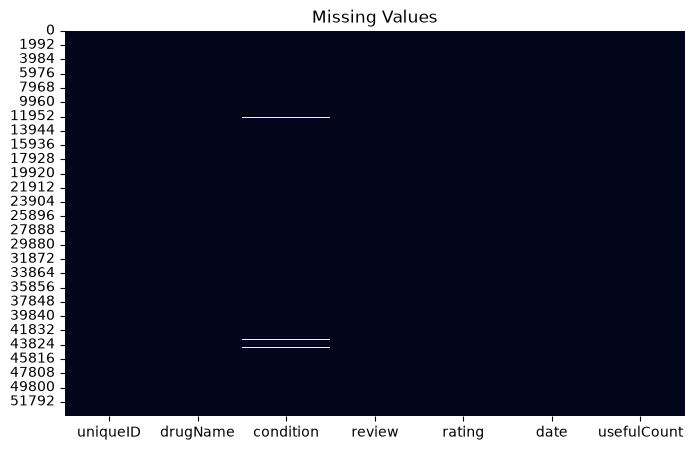

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [18]:
print("Missing condition values:", df['condition'].isna().sum())

Missing condition values: 295


In [19]:
# Filling up the missing records with 'unknown'
df['condition'] = df['condition'].fillna('Unknown')

 Missing values in condition were filled up with unknown to avoid: 
You retain potentially useful reviews.
You avoid unnecessarily reducing your dataset. 
You don't introduce a false condition by assigning the most common condition.

In [20]:
print("Missing condition values:", df['condition'].isna().sum())

Missing condition values: 0


In [22]:
# drop rows with missing values
df = df.dropna(subset=['condition'])

In [164]:
#  Drop missing review text 
df = df.dropna(subset=['review']).reset_index(drop=True)

In [23]:
# Count duplicate values in the review column
duplicate_count = df['review'].duplicated().sum()

print(f"Number of duplicate values in review column: {duplicate_count}")

Number of duplicate values in review column: 5486


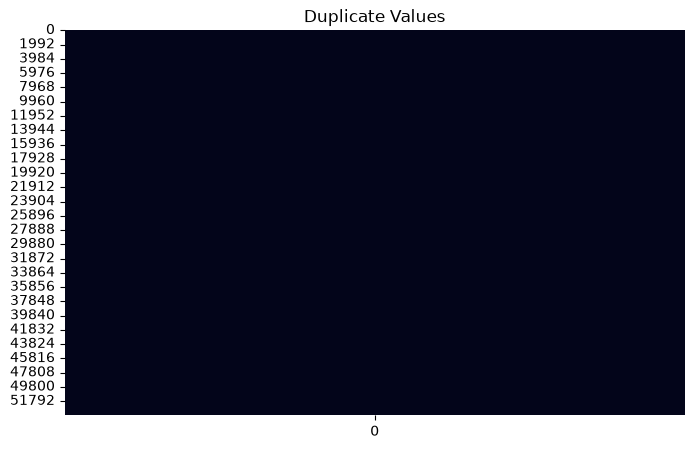

In [19]:
# CHECKING FOR MISSING VALUES
import matplotlib.pyplot as plt
import seaborn as sns

# Create a boolean mask for duplicate rows
duplicates = df.duplicated(keep=False)

# Plot duplicates as a heatmap
plt.figure(figsize=(8,5))
sns.heatmap(duplicates.to_frame(), cbar=False)
plt.title("Duplicate Values")
plt.show()

In [24]:
duplicate_text = df[df.duplicated('review', keep=False)]

print(duplicate_text['review'].value_counts().head(20))

review
"Good."                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                8
"Excellent"                                                                                                                                                                                                             

In [25]:
df.groupby('review')[['drugName', 'condition', 'rating']].nunique().sort_values(by='drugName', ascending=False)

,drugName,condition,rating
review,,,
"""Excellent""",7,6,2
"""Works great""",6,5,3
"""Good""",6,6,3
"""Good.""",6,5,3
"""Very good""",5,5,3
...,...,...,...
"""wow, this stuff will clean engines inside and out ha ha. nasty taste but very effective. won&#039;t do it again i can assure you that""",1,1,1
"""yes the hype is true with this med for appetite increase(also used for allergies which works wonders)\r\nthis will.. i repeat this medicine will make you sleepy, dizzy and a bit lazy the first few days...i would say give it a full week before the sleepiness becomes manageable \r\n\r\ni can recommend is taking 2mg then up the dose every few days **DO NOT take a full 4mg at first it will knock you on your butt\r\n(dissolving the tablet in juice or taking it with a full meal might help with the drowsiness)\r\nstarted this med at 100lbs 9 days later i&#039;m at 108lbs\r\n\r\ni rate it a 9 and not a full 10 because of the extreme drowsiness/sleepiness in the beginning \r\n\r\none last thing i recommend is to eat healthy foods to gain weight""",1,1,1
"""you will poo your pants within 1 hr of taking this product""",1,1,1


In [26]:
duplicate_reviews = df[df['review'].duplicated(keep=False)]

print("Number of duplicate-review rows:", len(duplicate_reviews))

Number of duplicate-review rows: 10931


In [27]:
duplicate_reviews[['review', 'drugName', 'condition', 'rating']].head(20)

,review,drugName,condition,rating
16,"""I smoked for 50+ years. Took it for one week...",Chantix,Smoking Cessation,10
17,"""So I was on Ginanvi for about 3 months before...",Microgestin Fe 1 / 20,Acne,3
18,"""This medication helped me sleep, but eventua...",Klonopin,Bipolar Disorde,6
26,"""klonopin has definitely given me my life back!""",Clonazepam,Panic Disorde,10
33,"""my advice on movantik is understand that mova...",Movantik,"Constipation, Drug Induced",1
36,"""Been on 30mg Cymbalta for 2 weeks. Started ge...",Duloxetine,Pain,9
44,"""Our condom seemed to not have worked properly...",Plan B One-Step,Emergency Contraception,8
45,"""I started on the oral contraceptive pill but ...",Ethinyl estradiol / etonogestrel,Birth Control,10
50,"""I&#039;ve had this birth control for a year n...",Etonogestrel,Birth Control,3
53,"""So I first got the nexplanon in July of 2014,...",Etonogestrel,Birth Control,5


In [28]:
duplicate_analysis = duplicate_reviews.groupby('review').agg({
    'drugName': 'nunique',
    'condition': 'nunique',
    'rating': 'nunique'
})

duplicate_analysis.head(20)

,drugName,condition,rating
review,,,
"""\r\nHell no, never again! severe stomach cramps not worth it !""",2,1,1
""" I&#039;m on my 2nd round of necon 1/35. I started taking it because the doctor thinks I have endometriosis, but no one is really sure. My periods are extremely painful and I lose my appetite completely. The side effects of necon are the same as symptoms of pregnancy which is kind of alarming. I&#039;m also even more depressed and anxious than I was before I started taking it. I take it without the placebo week and my period was lighter but longer. It&#039;s been two weeks and I&#039;ve still had terrible pain.""",2,1,1
""" It got rid of my cough but then made my nose run like crazy. Allergy symptoms while suffering from flu is a terrible combination. I am angry that my husband bought me this stuff instead of what I asked for. It kept me up all night and is making me irritable.""",2,1,1
""" On May 18th this guy came completely inside of me and he wasn&#039;t wearing a condom/I wasn&#039;t on birth control. Around 5 hours later I took plan B. On May 22nd I got my &quot;period&quot; which I later learned was withdrawal bleeding but anyways it was really heavy for a few days and then got progressively lighter. I had spotting for about a week and a half after the heavy days which has never happened to me but I read the pill can make your cycle irregular so I didn&#039;t worry too much about it. Around 11 days after the &#039;act&#039; I took a test and it was negative. I waited a week and took another test (so 18 days after the &#039;act&#039;) and it was negative! Not pregnant!! Yay!!""",2,1,1
"""&quot;just stopped because I have been on it to long, it will cause bone loss&quot;\r\r\n\r\r\n--&gt;Actually, this has recently been refuted! I almost had a hysterectomy last summer after my GYN told me I had to stop for bone loss &amp; the surgeon&#039;s a leading expert in her field - told me to ride the Depo Train as long as it prevents my god-awful periods &amp; then come back for the surgery. She emailed me the studies, so I verified the info myself.""",2,1,1
"""(Continuation) It was on the fourth month, my condition got better but still with bouts of migraine and what I noticed is that I somehow smell &quot;down there&quot;. Though my BV was treated more than five months ago, I became worried about it. Before the fifth pack, I forgot to take a pill so I had to follow how to continue it. I stopped by the fifth pack because I simply couldn&#039;t take it anymore. Migraine was so severe and depression and anxiety made me feel restless. I bled again. The smell of my discharge is not really good like there was something rotten (I don&#039;t use tampon). I gained weight too. Though I have lesser acne. But I can&#039;t prolong my agony anymore so I stopped.""",2,1,1
"""(continue) I get a feeling like my poor uterus is being stabbed , also horrible back pain, gained so much weight horrible acne and even more discharge like white stuff inside my vagina ( I never had that in my life) it grosses me out . I want to get it removed as soon as possible""",2,1,1
"""* EDIT last entry didn&#039;t include score\r\n\r\nI&#039;ve been on Lomaira for about 8 weeks and have had success. My doctor first put me on 37.5 mg generic phentermine, but I couldn&#039;t stop sweating and it was giving me anxiety. I was definitely eating less, but I hated the feeling. My doctor told me a new weight loss medication was now available that was more targeted to evening when I tend to over eat after work. It&#039;s definitely a bit more expensive. I&#039;m paying $29/month and the generic was about $18/month. I prefer the brand and I like starting on this low dose. You can go all the way up to 24mg with this so I will probably stay on lomaira for a while. I&#039;ve lost about 18 lbs in 2 months. I don&#039;t like drugs so I&#039;m happy to use less phentermine""",2,1,1
"""****** The product is called &quot;infant drops&quot;. Are there really infants that 

### Good → drugName = 2, condition = 1, rating = 2

means the review "Good":

appears across 2 different drugs
is associated with 1 condition
has 2 different ratings

This is more informative than simply knowing that "Good" is duplicated.

In [29]:
exact_duplicates = df[df.duplicated(
    subset=['review', 'drugName', 'condition', 'rating'],
    keep=False
)]

print("Exact duplicate rows:", len(exact_duplicates))

Exact duplicate rows: 16


In [30]:
df_clean = df.drop_duplicates(
    subset=['review', 'drugName', 'condition', 'rating'],
    keep='first'
)

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Duplicates removed:", len(df) - len(df_clean))

Original rows: 53766
Rows after removing duplicates: 53758
Duplicates removed: 8


In [31]:
# Remove duplicate reviews 
before = len(df)
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)
print(f'Removed {before - len(df)} duplicate reviews')

Removed 5486 duplicate reviews


Removing duplicates is crucial in dataset cleaning because it ensures that each data point is unique and correctly represented, which is essential for accurate analysis. Duplicates can lead to skewed results, inaccurate reporting, and poor decision-making. By removing duplicates, analysts can focus on the most relevant and reliable data, leading to more accurate insights and better business outcomes.

In [32]:
print(f'\nFinal dataset size: {df.shape}')
print(f'Missing values:\n{df.isnull().sum()}')


Final dataset size: (48280, 7)
Missing values:
uniqueID       0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64


# TEXT PREPROCESSING

In [33]:
# Drop identification columns and user profile information
df = df.drop(columns=[
    'uniqueID',
    'usefulCount',
    'date',
])

# Verify the remaining columns
print(df.columns)

Index(['drugName', 'condition', 'review', 'rating'], dtype='str')


# Download necessary NLTK 

In [34]:
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

In [35]:
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lebit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lebit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [36]:
df['review'].value_counts()
def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # Remove user mentions
    text = re.sub(r'@\w+', ' ', text)

    # Handle hashtags
    text = re.sub(r'#', '', text)

    # Keep alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)

    # Preserve sentiment-relevant words
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return ' '.join(tokens)
df['drugName'].value_counts()
df['condition'].value_counts()
df['rating'].value_counts()

rating
10    15318
9      8214
1      6516
8      5559
7      2757
5      2443
2      2093
3      1999
6      1892
4      1489
Name: count, dtype: int64

In [37]:
import pandas as pd


def label_sentiment(rating):
    if rating >= 8:
        return "Positive"
    elif rating >= 5:
        return "Neutral"
    else:
        return "Negative"

# Apply the function to create a new column
df["sentiment"] = df["rating"].apply(label_sentiment)

# Preview the updated DataFrame
print(df.head())

          drugName                     condition  \
0      Mirtazapine                    Depression   
1       Mesalamine  Crohn's Disease, Maintenance   
2          Bactrim       Urinary Tract Infection   
3         Contrave                   Weight Loss   
4  Cyclafem 1 / 35                 Birth Control   

                                              review  rating sentiment  
0  "I&#039;ve tried a few antidepressants over th...      10  Positive  
1  "My son has Crohn&#039;s disease and has done ...       8  Positive  
2                      "Quick reduction of symptoms"       9  Positive  
3  "Contrave combines drugs that were used for al...       9  Positive  
4  "I have been on this birth control for one cyc...       9  Positive  


In [38]:
df1 = df.copy()

In [39]:
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk import tokenize

In [40]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

print("Unique posts:", df['review'].nunique())

print("Sentiment distribution:")
print(df['sentiment'].value_counts())

Rows: 48280
Columns: 5
Missing values:
drugName     0
condition    0
review       0
rating       0
sentiment    0
dtype: int64
Duplicate rows: 0
Unique posts: 48280
Sentiment distribution:
sentiment
Positive    29091
Negative    12097
Neutral      7092
Name: count, dtype: int64


In [41]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')

# Initialize lemmatizer and stop words
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

print("NLTK setup completed successfully.")

NLTK setup completed successfully.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lebit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lebit\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [65]:
df['clean_review'] = df['review'].astype(str).apply(preprocess_text)

In [43]:
print(df.columns)

Index(['drugName', 'condition', 'review', 'rating', 'sentiment',
       'clean_review'],
      dtype='str')


# Set plot plan

In [44]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)

# Data Visualization

C:\Users\lebit\AppData\Local\Temp\ipykernel_13952\2074617928.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df, palette='cividis', order=sorted(df['rating'].unique()))


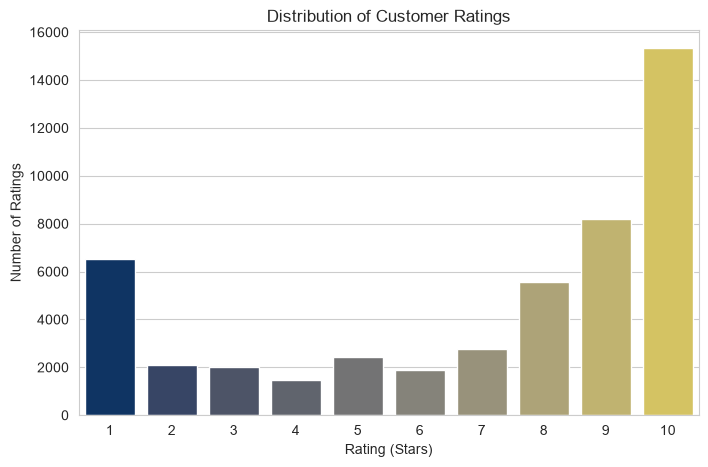

In [45]:
plt.figure(figsize=(8, 5))
sns.countplot(x='rating', data=df, palette='cividis', order=sorted(df['rating'].unique())) 
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating (Stars)') 
plt.ylabel('Number of Ratings')
plt.show()
# --> Changed: rating -> Rating

C:\Users\lebit\AppData\Local\Temp\ipykernel_13952\211208051.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='crest', order=sorted(df['sentiment'].unique()))


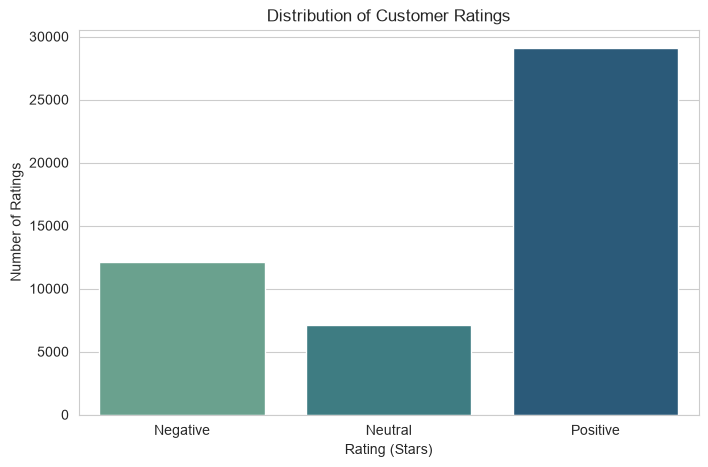

In [46]:
plt.figure(figsize=(8, 5))
sns.countplot(x='sentiment', data=df, palette='crest', order=sorted(df['sentiment'].unique())) 
plt.title('Distribution of Customer Ratings')
plt.xlabel('Rating (Stars)') 
plt.ylabel('Number of Ratings')
plt.show()

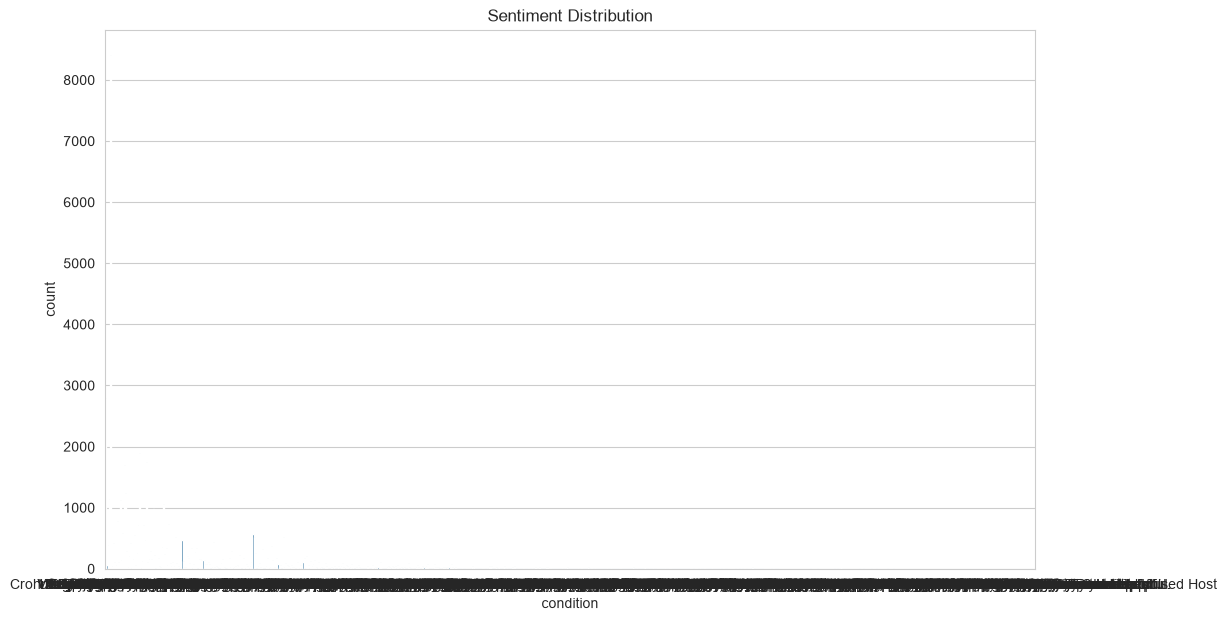

In [47]:
sns.countplot(x='condition', data=df)
plt.title("Sentiment Distribution")
plt.show()

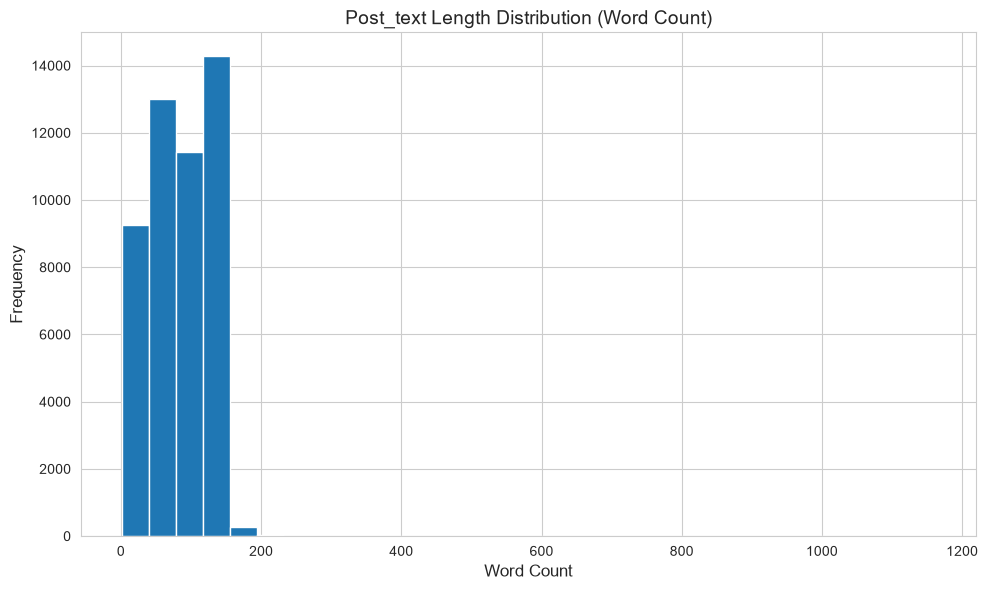

Mean review length: 84.6 words
Median review length: 84 words


In [48]:
import matplotlib.pyplot as plt

# Create a new column containing the word count of each post
df['review_length_words'] = df['review'].astype(str).apply(lambda x: len(x.split()))

# Plot the distribution of word counts
plt.figure(figsize=(10, 6))
plt.hist(df['review_length_words'], bins=30)

# Customize the plot
plt.title('Post_text Length Distribution (Word Count)', fontsize=14)
plt.xlabel('Word Count', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Improve layout
plt.tight_layout()
# Display the plot
plt.show()
print(f'Mean review length: {df["review_length_words"].mean():.1f} words')
print(f'Median review length: {df["review_length_words"].median():.0f} words')

In [49]:
# ── 4.2 Review length distribution ────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.hist(df['word_count_raw'], bins=40, color='coral', edgecolor='white')
plt.title('Distribution of Review Length (Word Count)', fontsize=13)
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('review_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Mean review length: {df["word_count_raw"].mean():.1f} words')
print(f'Median review length: {df["word_count_raw"].median():.0f} words')

KeyError: 'word_count_raw'

<Figure size 1000x500 with 0 Axes>

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

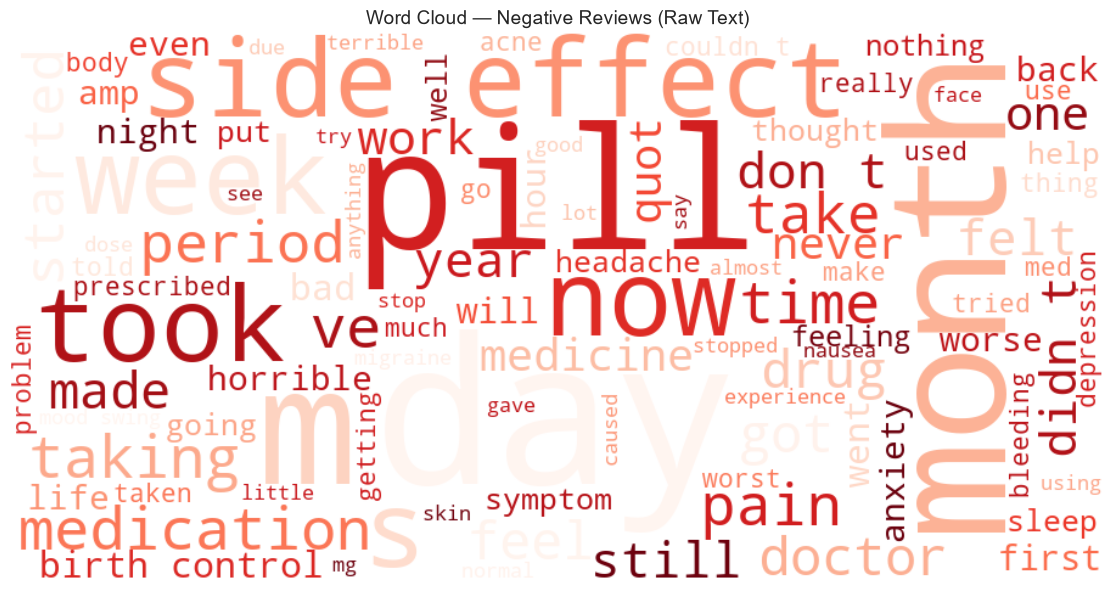

Common words include generic terms ("quick", "reduction", "of", "symptoms") that will be removed in preprocessing.


In [51]:
# ── 4.3 Word cloud — negative reviews (before cleaning) ───────────────
# Early visual impression of dominant complaint themes
negative_text = ' '.join(df[df['rating'] <= 2]['review'].astype(str))

wc = WordCloud(width=900, height=450, background_color='white',
               colormap='Reds', max_words=100).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud — Negative Reviews (Raw Text)', fontsize=14)
plt.tight_layout()
plt.savefig('wordcloud_raw_negative.png', dpi=150, bbox_inches='tight')
plt.show()
print('Common words include generic terms ("quick", "reduction", "of", "symptoms") that will be removed in preprocessing.')

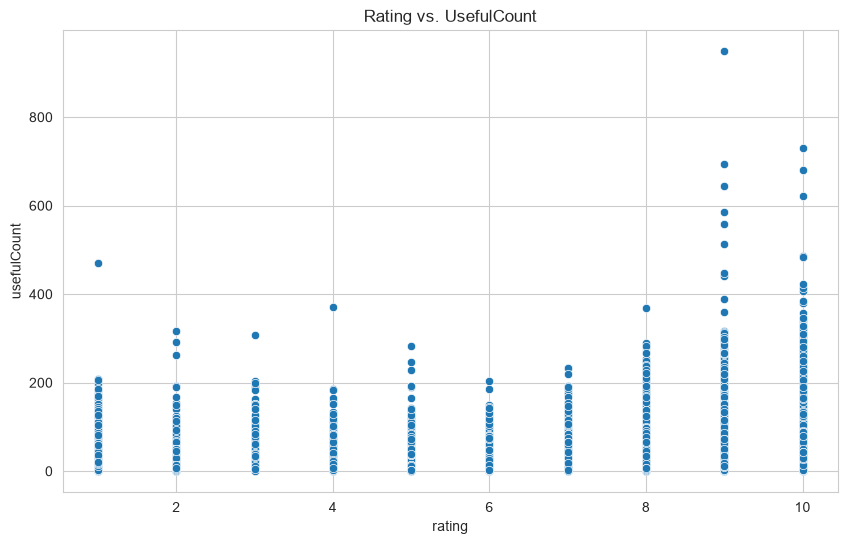

In [161]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='rating', y='usefulCount', data=df)
plt.title('Rating vs. UsefulCount')
plt.xlabel('rating')
plt.ylabel('usefulCount')

plt.show()

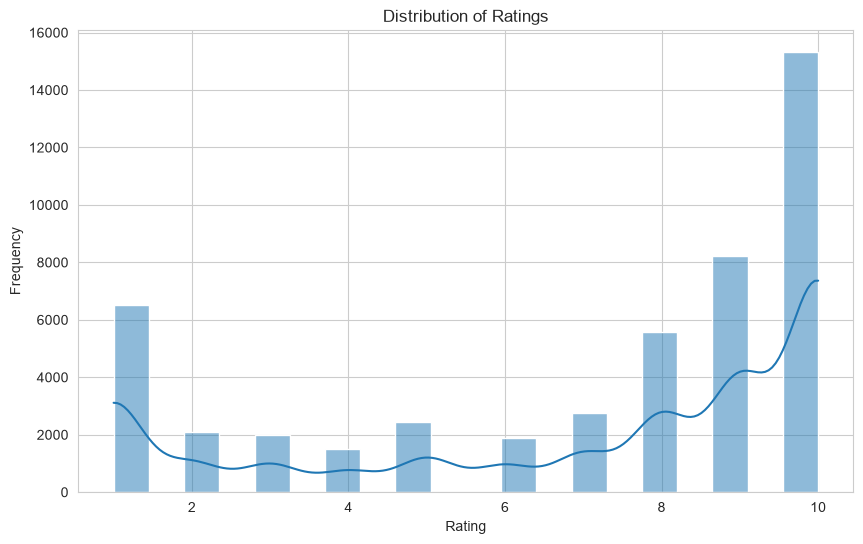

In [52]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'].dropna(), bins=20, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [53]:
plt.figure(figsize=(12, 6))

top_10_countries = df['condition'].value_counts().head(10).index

df_top_10_countries = df[['condition'].isin(top_10_conditions)]

sns.countplot(x='condition', hue='sentiment', data=df_top_10_countries, palette='Paired')
plt.title('Relationship between Country and Sentiment (Top 10 Countries)')
plt.xlabel('condition')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

AttributeError: 'list' object has no attribute 'isin'

<Figure size 1200x600 with 0 Axes>

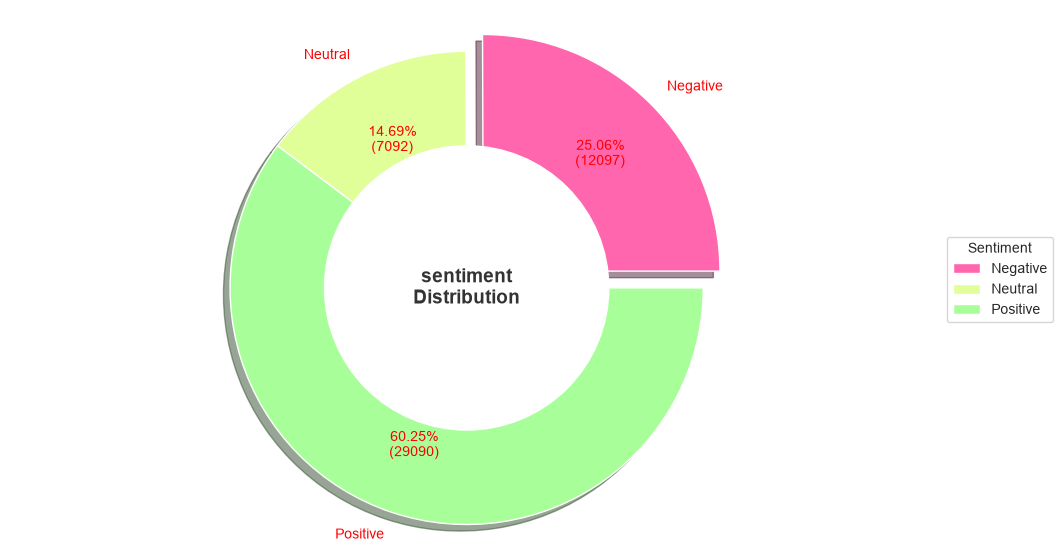

In [53]:
colors = ["#ff66ad", "#e0ff99", "#a8ff99"]

explode = (0.1, 0, 0)  

sentiment_counts = df.groupby("sentiment").size()

fig, ax = plt.subplots()

wedges, texts, autotexts = ax.pie(
    x=sentiment_counts, 
    labels=sentiment_counts.index,
    autopct=lambda p: f'{p:.2f}%\n({int(p*sum(sentiment_counts)/100)})', 
    wedgeprops=dict(width=0.7),
    textprops=dict(size=10, color="r"),  
    pctdistance=0.7,
    colors=colors,
    explode=explode,
    shadow=True)

center_circle = plt.Circle((0, 0), 0.6, color='white', fc='white', linewidth=1.25)
fig.gca().add_artist(center_circle)

ax.text(0, 0, 'sentiment\nDistribution', ha='center', va='center', fontsize=14, fontweight='bold', color='#333333')

ax.legend(sentiment_counts.index, title="Sentiment", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

ax.axis('equal')  

plt.show()

# Word frequency

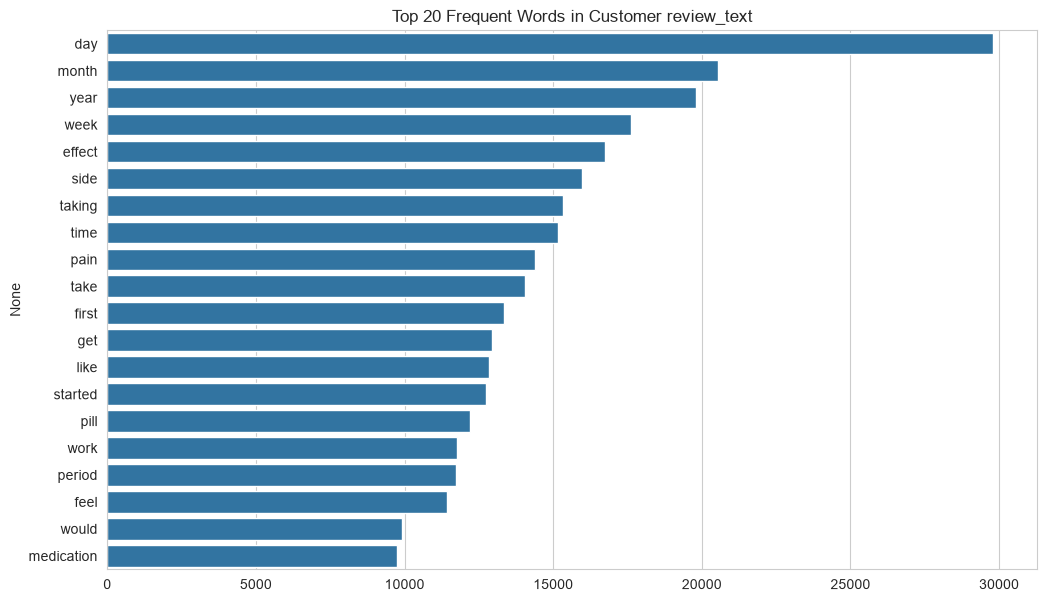

In [54]:
word_freq = pd.Series(" ".join(df['clean_review']).split()).value_counts()[:20]
sns.barplot(x=word_freq.values, y=word_freq.index)
plt.title("Top 20 Frequent Words in Customer review_text")
plt.show()


In [55]:
from collections import Counter

df1['temp_list'] = df['clean_review'].apply(lambda x: str(x).split())

top_words = Counter(
    [item for sublist in df1['temp_list'] for item in sublist]
)

top_words_df = pd.DataFrame(
    top_words.most_common(20),
    columns=['Common_words', 'count']
)

top_words_df.style.background_gradient(cmap='Blues')

,Common_words,count
0,day,29796
1,month,20540
2,year,19795
3,week,17602
4,effect,16751
5,side,15981
6,taking,15321
7,time,15166
8,pain,14386
9,take,14039


In [57]:
import plotly.express as px
from collections import Counter
import pandas as pd

# Split cleaned text into words
df1['temp_list'] = df['clean_review'].apply(
    lambda x: str(x).split()
)

# Count the words
top_words = Counter(
    item
    for sublist in df1['temp_list']
    for item in sublist
)

# Create DataFrame of the 20 most common words
top_words_df = pd.DataFrame(
    top_words.most_common(20),
    columns=['Common_words', 'count']
)

# Create bar chart
fig = px.bar(
    top_words_df,
    x='count',
    y='Common_words',
    title='Common Words in Text Data',
    orientation='h'
)

fig.show()

In [58]:
top = Counter([item for sublist in df1[df1['sentiment'] == 'Neutral']['temp_list'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(10), columns=['Common_words', 'count'])
temp_positive.style.background_gradient(cmap='Blues')


,Common_words,count
0,day,4570
1,month,3655
2,week,2957
3,year,2650
4,taking,2637
5,effect,2564
6,side,2486
7,time,2419
8,period,2309
9,first,2264


In [59]:
top = Counter([item for sublist in df1[df1['sentiment'] == 'Positive']['temp_list'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(10), columns=['Common_words', 'count'])
temp_positive.style.background_gradient(cmap='Greens')

,Common_words,count
0,day,18034
1,year,13879
2,month,11194
3,effect,10801
4,side,10330
5,week,10172
6,take,9384
7,time,9089
8,taking,8750
9,pain,8483


### Negative common words

In [60]:
top = Counter([item for sublist in df1[df1['sentiment'] == 'Negative']['temp_list'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(10), columns=['Common_words', 'count'])
temp_positive.style.background_gradient(cmap='Purples')


,Common_words,count
0,day,7192
1,month,5691
2,week,4473
3,taking,3934
4,pain,3728
5,time,3658
6,like,3515
7,pill,3485
8,effect,3386
9,year,3266


In [61]:
top = Counter([item for sublist in df1[df1['sentiment'] == 'Neutral']['temp_list'] for item in sublist])
temp_positive = pd.DataFrame(top.most_common(10), columns=['Common_words', 'count'])
temp_positive.style.background_gradient(cmap='Reds')


,Common_words,count
0,day,4570
1,month,3655
2,week,2957
3,year,2650
4,taking,2637
5,effect,2564
6,side,2486
7,time,2419
8,period,2309
9,first,2264


# LDA MODELLING

In [66]:
print(df.columns)


Index(['drugName', 'condition', 'review', 'rating', 'sentiment',
       'clean_review', 'review_length_words'],
      dtype='str')


In [67]:
print(df1.columns.tolist())

['drugName', 'condition', 'review', 'rating', 'sentiment', 'temp_list']


In [68]:
print('clean_review' in df1.columns)

False


In [69]:
print(df.columns.tolist())
print(df1.columns.tolist())

['drugName', 'condition', 'review', 'rating', 'sentiment', 'clean_review', 'review_length_words']
['drugName', 'condition', 'review', 'rating', 'sentiment', 'temp_list']


In [73]:
df1['clean_review'] = df1['review'].apply(preprocess_text)

In [74]:
# ── Prepare negative review corpus 
negative_df = df1[df1['sentiment'] == 'Negative'].reset_index(drop=True)
print(f'Number of negative reviews for topic modelling: {len(negative_df)}')

# ── Bag-of-words vectorisation 
# max_df: ignore words appearing in >90% of documents (too generic)
# min_df: ignore words appearing in <5 documents (too rare/noisy)
count_vectorizer = CountVectorizer(max_df=0.9, min_df=5, max_features=50000)
doc_term_matrix = count_vectorizer.fit_transform(negative_df['clean_review'])

print(f'Document-term matrix shape: {doc_term_matrix.shape}')

Number of negative reviews for topic modelling: 12097
Document-term matrix shape: (12097, 4842)


In [75]:
# ── Train final LDA model ─────────────────────────────────────────────
# n_components=6: balances granularity with interpretability for a business audience
N_TOPICS = 6
lda_model = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=10,
    learning_method='online',
    random_state=42
)
lda_model.fit(doc_term_matrix)

print(f'LDA model trained with {N_TOPICS} topics.')
print(f'Final perplexity: {lda_model.perplexity(doc_term_matrix):.2f}')

LDA model trained with 6 topics.
Final perplexity: 1077.31


In [76]:
# ── Display top words per topic ───────────────────────────────────────
feature_names = count_vectorizer.get_feature_names_out()

def display_topics(model, feature_names, n_top_words=10):
    topics_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        topics_dict[f'Topic {topic_idx + 1}'] = top_words
        print(f'Topic {topic_idx + 1}: {", ".join(top_words)}')
    return topics_dict

print('=== Top 10 Words per Topic ===\n')
topics_dict = display_topics(lda_model, feature_names, n_top_words=10)

=== Top 10 Words per Topic ===

Topic 1: day, night, time, took, sleep, hour, taking, take, first, felt
Topic 2: month, period, pill, week, control, day, birth, bleeding, get, first
Topic 3: day, like, pain, amp, never, take, get, infection, would, use
Topic 4: pain, effect, side, drug, doctor, severe, taking, medication, year, quot
Topic 5: month, year, week, skin, work, worse, hair, face, acne, injection
Topic 6: anxiety, effect, side, taking, day, medication, depression, week, feel, started


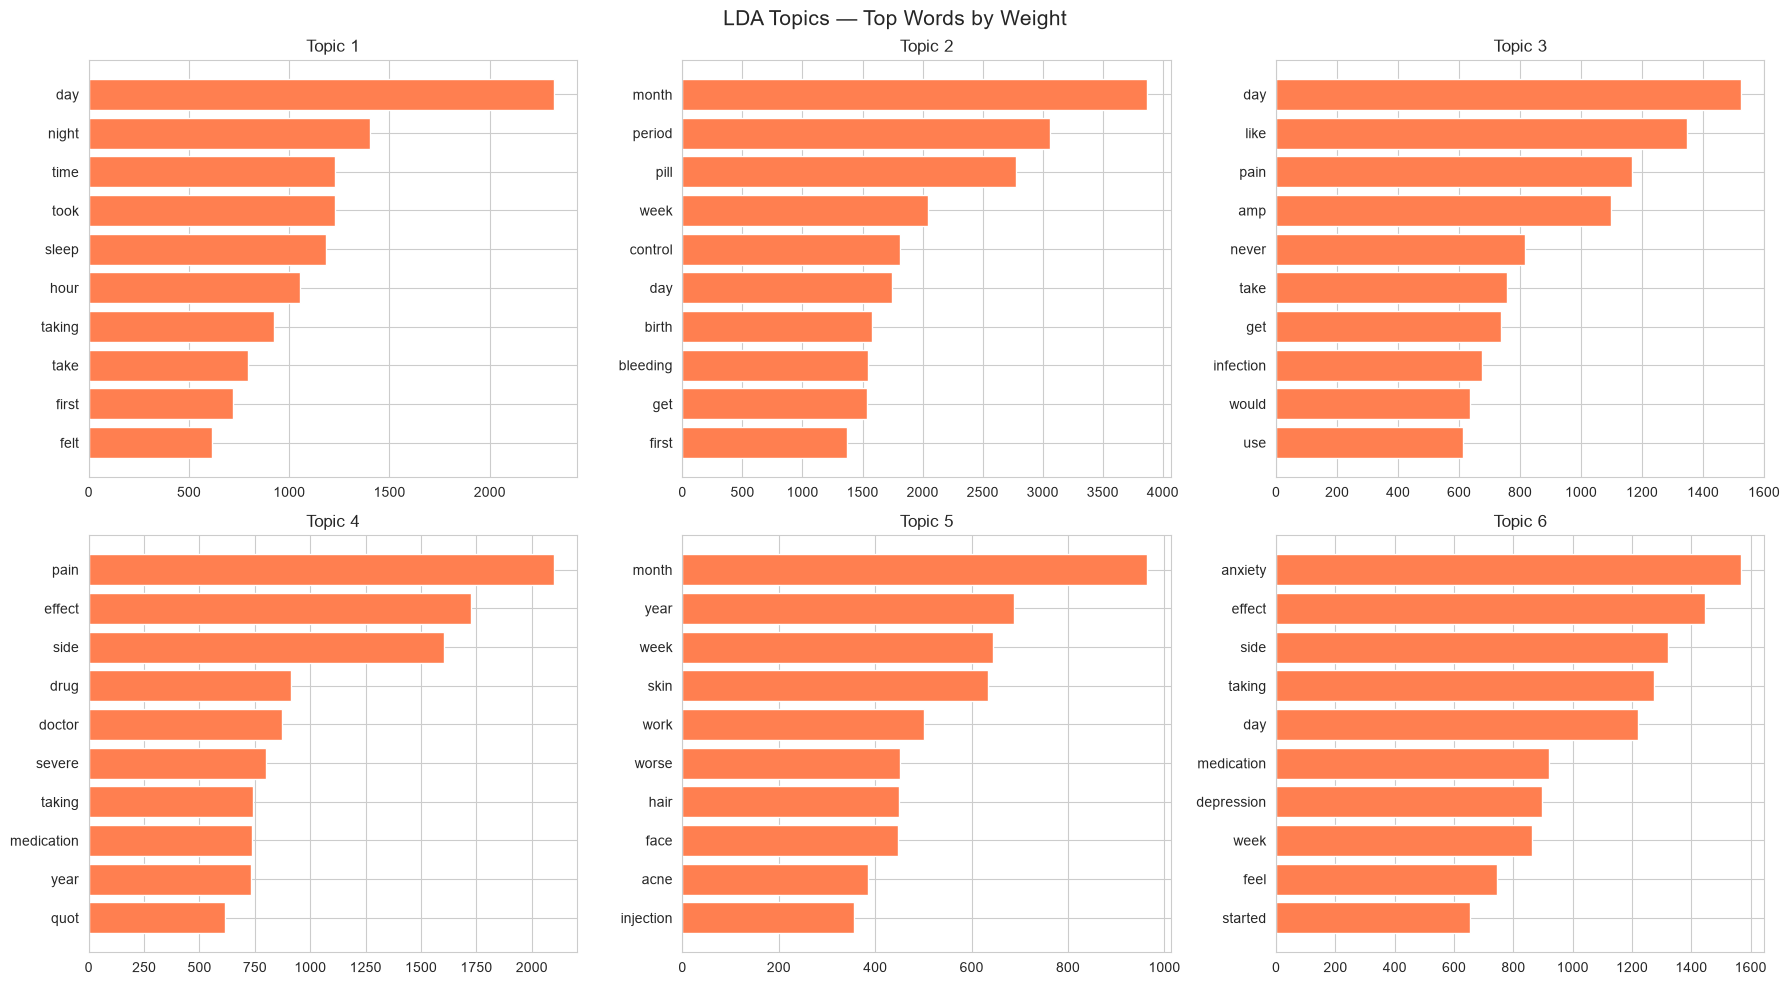

In [77]:
# ── Visualise topic-word distributions ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for topic_idx, topic in enumerate(lda_model.components_):
    top_indices = topic.argsort()[:-11:-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]

    axes[topic_idx].barh(top_words[::-1], top_weights[::-1], color='coral')
    axes[topic_idx].set_title(f'Topic {topic_idx + 1}', fontsize=12)

plt.suptitle('LDA Topics — Top Words by Weight', fontsize=15)
plt.tight_layout()
plt.savefig('lda_topics_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

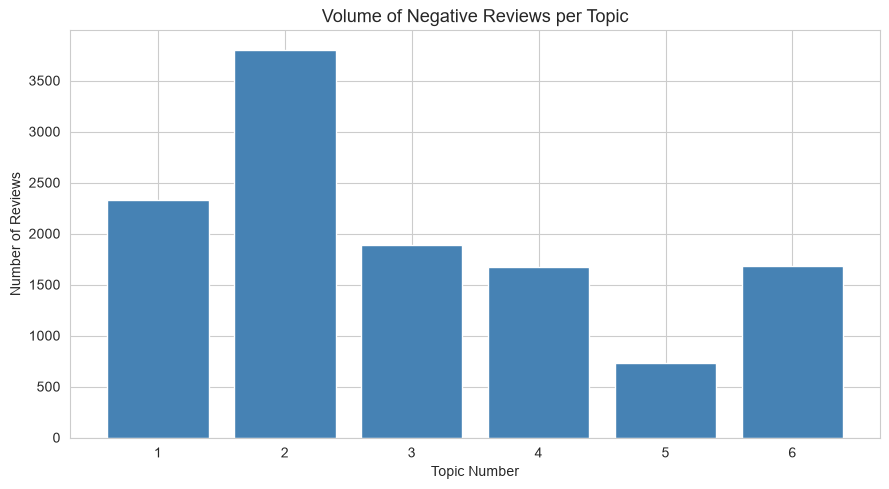

dominant_topic
1    2330
2    3801
3    1887
4    1673
5     728
6    1678
Name: count, dtype: int64

Largest area of concern: Topic 2 with 3801 reviews (31.4%)


In [78]:
# ── Assign dominant topic to each negative review ─────────────────────
topic_distribution = lda_model.transform(doc_term_matrix)
negative_df['dominant_topic'] = topic_distribution.argmax(axis=1) + 1

# Visualise how many reviews fall under each topic
plt.figure(figsize=(9, 5))
topic_counts = negative_df['dominant_topic'].value_counts().sort_index()
plt.bar(topic_counts.index.astype(str), topic_counts.values, color='steelblue', edgecolor='white')
plt.xlabel('Topic Number')
plt.ylabel('Number of Reviews')
plt.title('Volume of Negative Reviews per Topic', fontsize=13)
plt.tight_layout()
plt.savefig('topic_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(topic_counts)
print(f'\nLargest area of concern: Topic {topic_counts.idxmax()} with {topic_counts.max()} reviews ({topic_counts.max()/len(negative_df)*100:.1f}%)')

# TRAINING THE MODEL

In [79]:
df2 = df1.copy()

In [80]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

In [83]:
# Define features (X) and target (y)
X = df2['clean_review']
y = df2['sentiment']

In [96]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [98]:
print("Training samples:", X_train_text.shape[0])
print("Testing samples:", X_test_text.shape[0])

Training samples: 38624
Testing samples: 9656


In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    min_df=2,
    max_df=0.95
)

X = tfidf.fit_transform(df2['clean_review'])
y = df2['sentiment']

In [94]:
print("Number of samples in X:", X_train_text.shape[0])
print("Number of labels in y:", len(y_train))

Number of samples in X: 38624
Number of labels in y: 38624


In [99]:
# Train a Logistic Regression model
print("Training Sentiment Analysis model (Logistic Regression)...")
model_sentiment = LogisticRegression(max_iter=1000, random_state=42)
model_sentiment.fit(X_train_text, y_train)

Training Sentiment Analysis model (Logistic Regression)...


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [101]:
# Predict and evaluate
print("Evaluating Sentiment Analysis model...")
y_pred_sent = model_sentiment.predict(X_test_text)
accuracy_sent = accuracy_score(y_test, y_pred_sent)
report_sent = classification_report(y_test, y_pred_sent)

print(f"\nSentiment Analysis Accuracy: {accuracy_sent:.4f}")
print("Classification Report:")
print(report_sent)

Evaluating Sentiment Analysis model...

Sentiment Analysis Accuracy: 0.7304
Classification Report:
              precision    recall  f1-score   support

    Negative       0.68      0.64      0.66      2419
     Neutral       0.40      0.12      0.19      1419
    Positive       0.77      0.92      0.84      5818

    accuracy                           0.73      9656
   macro avg       0.62      0.56      0.56      9656
weighted avg       0.69      0.73      0.70      9656



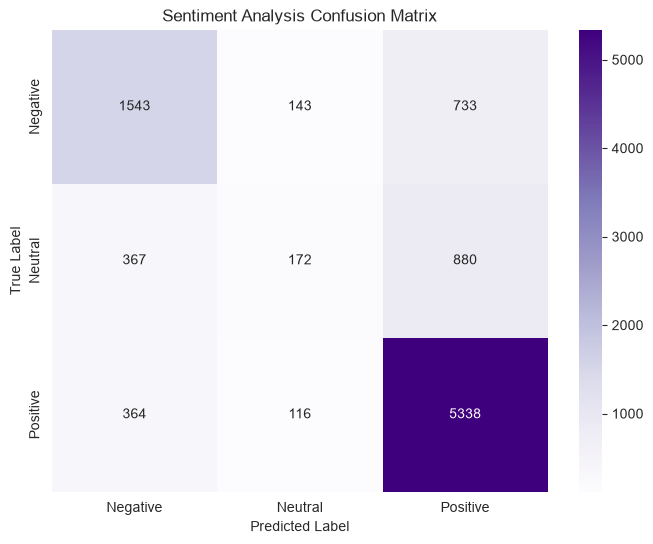

In [103]:
# Fitting Confusion Matrix
plt.figure(figsize=(8, 6))
cm_sent = confusion_matrix(y_test, y_pred_sent, labels=model_sentiment.classes_)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Purples', xticklabels=model_sentiment.classes_, yticklabels=model_sentiment.classes_)
plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [108]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train SVM model
print("Training Sentiment Analysis model (SVM)...")

svm_model = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=2000
)

svm_model.fit(X_train_text, y_train)

print("SVM model trained successfully!")

Training Sentiment Analysis model (SVM)...
SVM model trained successfully!


In [109]:
# Predict sentiment on the test data
y_pred_svm = svm_model.predict(X_test_text)

print("SVM predictions completed.")

SVM predictions completed.


In [110]:
# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"SVM Accuracy: {svm_accuracy:.4f}")

SVM Accuracy: 0.7172


In [111]:
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))


SVM Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.65      0.65      2419
     Neutral       0.32      0.12      0.18      1419
    Positive       0.77      0.89      0.83      5818

    accuracy                           0.72      9656
   macro avg       0.58      0.55      0.55      9656
weighted avg       0.68      0.72      0.69      9656



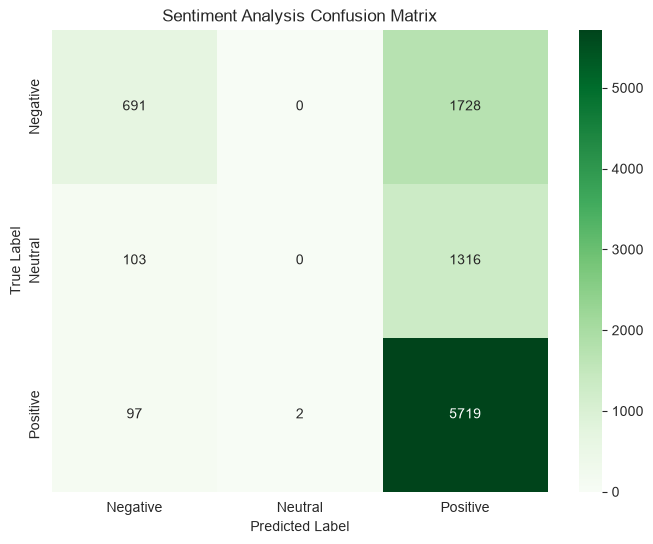

In [113]:
# Fitting Confusion Matrix
plt.figure(figsize=(8, 6))
cm_sent = confusion_matrix(y_test, y_pred_sent, labels=model_sentiment.classes_)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Greens', xticklabels=model_sentiment.classes_, yticklabels=model_sentiment.classes_)
plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [34]:
data_features.getnnz()

3157676

In [35]:
print("Density of the matrix: ",
    data_features.getnnz()*100 /  
    (data_features.shape[0]* data_features.shape[1]))

Density of the matrix:  0.17465645052353737


# Feature Engineering

In [113]:
print(df.columns)

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount', 'word_count_raw', 'processed_text', 'dominant_topic',
       'clean_text'],
      dtype='str')


# Sentiment Analysis (Predicting Sentiment)

In [114]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [115]:
# Train a Naive Bayes model
model_sentiment = MultinomialNB()
model_sentiment.fit(X_train_text, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](3,)","[ 9678., 5673.,23273.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](3,)","[-1.38,-1.92,-0.51]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U8](3,)","['Negative','Neutral','Positive']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](3, 10000)","[[ 0. , 0.26, 0.23,..., 4.51, 3.29, 0. ], [ 0. , 0.19, 0. ,..., 4.17, 3.9 , 0.46], [ 0.39, 1.73, 0.61,...,14.48,11.91, 0.93]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](3, 10000)","[[-10.98,-10.75,-10.77,..., -9.27, -9.52,-10.98], [-10.59,-10.41,-10.59,..., -8.94, -9. ,-10.21], [-11.43,-10.76,-11.29,..., -9.03, -9.21,-11.11]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [116]:
# Predict and evaluate
print("Evaluating Sentiment Analysis model...")
y_pred_sent = model_sentiment.predict(X_test_text)
accuracy_sent = accuracy_score(y_test, y_pred_sent)
report_sent = classification_report(y_test, y_pred_sent)


Evaluating Sentiment Analysis model...


In [117]:
print(f"\nSentiment Analysis Accuracy: {accuracy_sent:.4f}")
print("Classification Report:")
print(report_sent)


Sentiment Analysis Accuracy: 0.6638
Classification Report:
              precision    recall  f1-score   support

    Negative       0.78      0.29      0.42      2419
     Neutral       0.00      0.00      0.00      1419
    Positive       0.65      0.98      0.78      5818

    accuracy                           0.66      9656
   macro avg       0.48      0.42      0.40      9656
weighted avg       0.59      0.66      0.58      9656



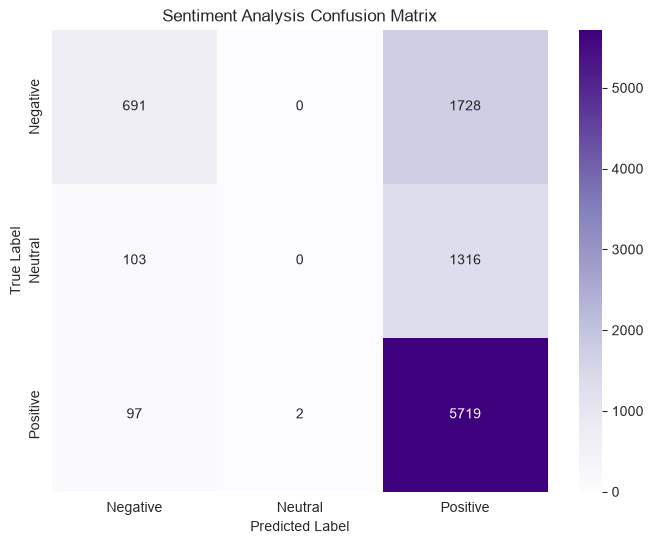

In [120]:
# Fitting Confusion Matrix
plt.figure(figsize=(8, 6))
cm_sent = confusion_matrix(y_test, y_pred_sent, labels=model_sentiment.classes_)
sns.heatmap(cm_sent, annot=True, fmt='d', cmap='Purples', xticklabels=model_sentiment.classes_, yticklabels=model_sentiment.classes_)
plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Rating Predictions

In [118]:
print("\n--- Task 2: Rating Prediction ---")

# Define features (X) and target (y)
# Using the same TF-IDF features
X_rating = X_tfidf
y_rating = df['rating'] 

# Split data - stratify might be important due to rating distribution
X_train_rate, X_test_rate, y_train_rate, y_test_rate = train_test_split(
    X_rating, y_rating, test_size=0.25, random_state=42, stratify=y_rating # --> Changed: y_rating
)


--- Task 2: Rating Prediction ---


NameError: name 'X_tfidf' is not defined

In [144]:
# Train a Linear SVC model (often good for text classification)
print("Training Rating Prediction model (Linear SVC)...")

model_rating = LinearSVC(random_state=42, C=0.5, max_iter=2000, dual=True)
model_rating.fit(X_train_rate, y_train_rate)

Training Rating Prediction model (Linear SVC)...


,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_iter max_iter: int, default=1000The maximum number of iterations to be run.",2000
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supp

In [145]:
# Predict and evaluate
print("Evaluating Rating Prediction model...")
y_pred_rate = model_rating.predict(X_test_rate)
accuracy_rate = accuracy_score(y_test_rate, y_pred_rate)
report_rate = classification_report(y_test_rate, y_pred_rate)
mae_rate = mean_absolute_error(y_test_rate, y_pred_rate) 

Evaluating Rating Prediction model...


In [146]:
print(f"\nRating Prediction Accuracy: {accuracy_rate:.4f}")
print(f"Rating Prediction Mean Absolute Error (MAE): {mae_rate:.4f}") 
print("Classification Report:")
print(report_rate)


Rating Prediction Accuracy: 0.4013
Rating Prediction Mean Absolute Error (MAE): 1.8378
Classification Report:
              precision    recall  f1-score   support

           1       0.46      0.68      0.55      1619
           2       0.13      0.03      0.05       521
           3       0.12      0.04      0.06       497
           4       0.05      0.01      0.02       368
           5       0.19      0.08      0.11       606
           6       0.13      0.03      0.05       468
           7       0.15      0.06      0.09       684
           8       0.22      0.16      0.18      1380
           9       0.25      0.22      0.23      2038
          10       0.50      0.76      0.60      3795

    accuracy                           0.40     11976
   macro avg       0.22      0.21      0.19     11976
weighted avg       0.32      0.40      0.34     11976



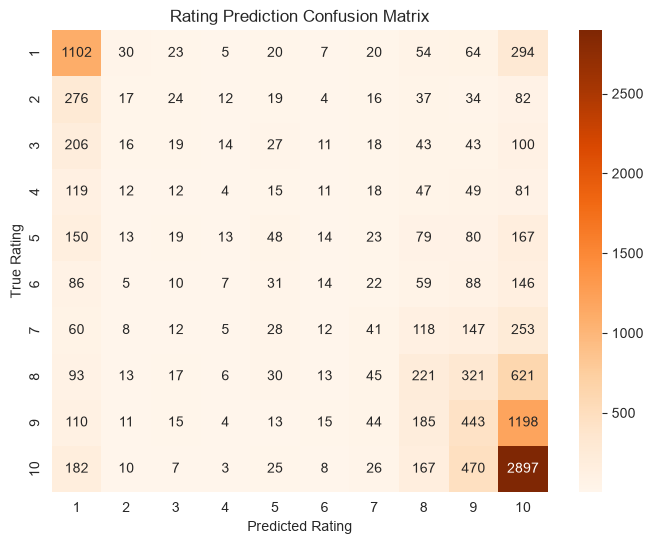

In [147]:
# Confusion Matrix
plt.figure(figsize=(8, 6))

rating_labels = sorted(y_rating.unique())
cm_rate = confusion_matrix(y_test_rate, y_pred_rate, labels=rating_labels)
sns.heatmap(cm_rate, annot=True, fmt='d', cmap='Oranges', xticklabels=rating_labels, yticklabels=rating_labels)
plt.title('Rating Prediction Confusion Matrix')
plt.xlabel('Predicted Rating') 
plt.ylabel('True Rating') 
plt.show()


In [150]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [154]:
# Trining a Randomforest model
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [153]:
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    random_state=42,
    class_weight="balanced" # useful if ratings are imbalanced
)
rf_model.fit(X_train_rate, y_train_rate)

# Predict on test set
y_pred_rate = rf_model.predict(X_test_rate)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test_rate, y_pred_rate))
print("\nClassification Report:\n", classification_report(y_test_rate, y_pred_rate))

Accuracy: 0.37132598530394123

Classification Report:
               precision    recall  f1-score   support

           1       0.39      0.66      0.49      1619
           2       0.26      0.02      0.03       521
           3       0.11      0.01      0.02       497
           4       0.00      0.00      0.00       368
           5       0.07      0.01      0.01       606
           6       0.25      0.00      0.01       468
           7       0.11      0.01      0.02       684
           8       0.17      0.13      0.14      1380
           9       0.24      0.24      0.24      2038
          10       0.45      0.71      0.55      3795

    accuracy                           0.37     11976
   macro avg       0.20      0.18      0.15     11976
weighted avg       0.29      0.37      0.30     11976



# Topic Modelling

In [122]:
print("\n--- Task 3: Topic Modeling (LDA) ---") 

# Create CountVectorizer features for LDA
print("Creating CountVectorizer features for LDA...")
count_vectorizer = CountVectorizer(max_df=0.95, min_df=2, 
                                 max_features=8000,     
                                 stop_words='english')
X_count = count_vectorizer.fit_transform(df1['clean_review']) 
print("CountVectorizer features created.")

# Define the number of topics
n_topics = 10

# Train the LDA model
print(f"Training LDA model with {n_topics} topics...")
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, n_jobs=-1) 
lda.fit(X_count)
print("LDA model training complete.")


--- Task 3: Topic Modeling (LDA) ---
Creating CountVectorizer features for LDA...
CountVectorizer features created.
Training LDA model with 10 topics...
LDA model training complete.


In [123]:
# Function to display topics
def display_topics(model, feature_names, n_top_words):
    print("\n--- Identified Topics ---")
    for topic_idx, topic in enumerate(model.components_):
        message = f"Topic #{topic_idx}: "
        message += " | ".join([feature_names[i]
                             for i in topic.argsort()[:-n_top_words - 1:-1]])
        print(message)

In [124]:
# Display the top words for each topic
n_top_words = 5
feature_names = count_vectorizer.get_feature_names_out()
display_topics(lda, feature_names, n_top_words)



--- Identified Topics ---
Topic #0: weight | day | week | lb | lost
Topic #1: work | year | insurance | use | patch
Topic #2: pain | year | day | effect | migraine
Topic #3: day | sleep | night | taking | hour
Topic #4: period | pill | month | day | week
Topic #5: day | infection | took | time | like
Topic #6: anxiety | life | feel | depression | year
Topic #7: year | amp | quot | month | blood
Topic #8: month | period | year | got | weight
Topic #9: skin | acne | month | week | year


# Assign dominant topic to each review

In [125]:
topic_results = lda.transform(X_count)
df['dominant_topic'] = topic_results.argmax(axis=1)
print("\nDominant topic assigned to each review (sample):")
print(df[['review', 'dominant_topic']].head()) 



Dominant topic assigned to each review (sample):
                                              review  dominant_topic
0  "I&#039;ve tried a few antidepressants over th...               6
1  "My son has Crohn&#039;s disease and has done ...               2
2                      "Quick reduction of symptoms"               2
3  "Contrave combines drugs that were used for al...               0
4  "I have been on this birth control for one cyc...               4


# Plotting the sentiment distribution

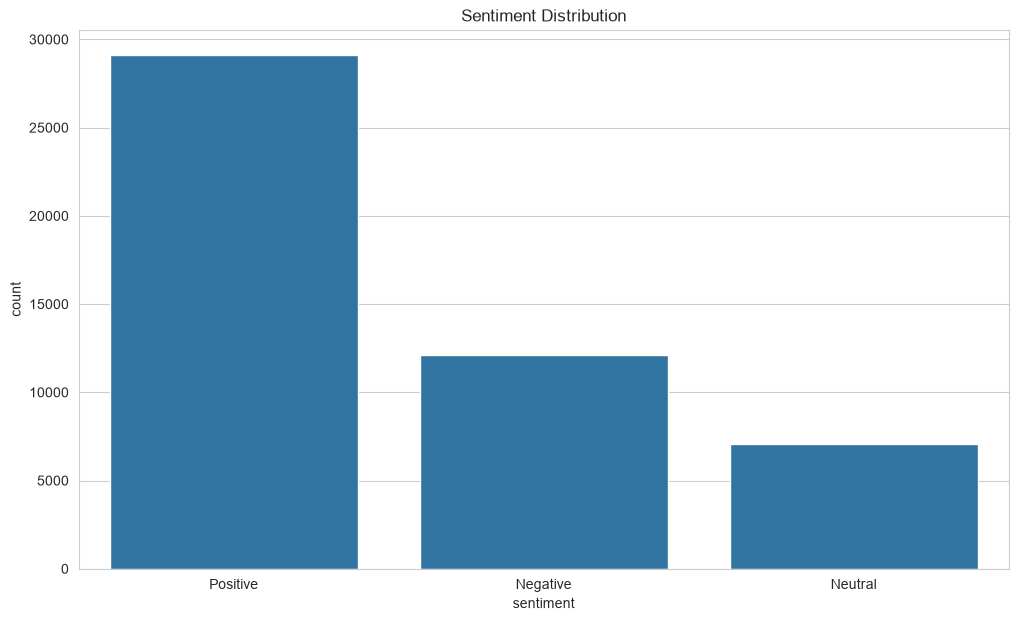

In [126]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()